BASIC WAVETABLE SYNTHESIS

In [3]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.io import wavfile 
from scipy.signal import butter, lfilter_zi, lfilter
from scipy.signal import convolve
from IPython.display import Audio

In [4]:
sample_rate = 44100
frequency = 440.0
duration = 2.0
loss = 0.996
t = np.linspace(0, 1, num=100)

In [21]:
total_samples = int(sample_rate * duration)
tube_len = int(sample_rate / frequency / 2 ) 

open_bc = -0.997
closed_bc = 0.999

left_delay_line = np.zeros(tube_len) #Sound wave traveling from closed to open, incident 
right_delay_line = np.zeros(tube_len) #Sound wave traveling from open to closed, reflected
wt_syn_output=np.zeros(total_samples) #At time zero, no output

for i in range(total_samples):
    wt_syn_output[i] = right_delay_line[-1] + left_delay_line[-1] #output is measured at open, right, end
    new_left_entry = right_delay_line[-1] * open_bc #right wave travels to open end and is reflected
    new_right_entry = left_delay_line[0] * closed_bc #left wave travels to closed end and is bounced

    if i < tube_len:
        new_right_entry += np.random.uniform(-1.0,1.0) #excitation

    left_delay_line = np.append(left_delay_line[1:], new_left_entry) # new entry at right end
    right_delay_line = np.append(new_right_entry, right_delay_line[:-1]) # new entry at left end

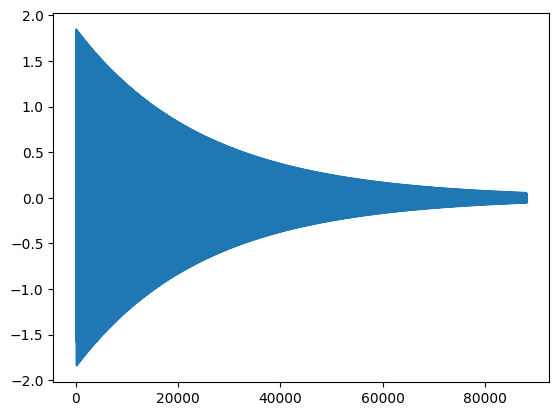

In [22]:
plt.plot(wt_syn_output)

(array([1.78086257e-12, 1.78092552e-12, 1.78111454e-12, ...,
        6.22369661e-11, 6.22307895e-11, 6.22287309e-11], shape=(44101,)),
 array([0.00000e+00, 5.00000e-01, 1.00000e+00, ..., 2.20490e+04,
        2.20495e+04, 2.20500e+04], shape=(44101,)),
 <matplotlib.lines.Line2D at 0x23a6f6a2d50>)

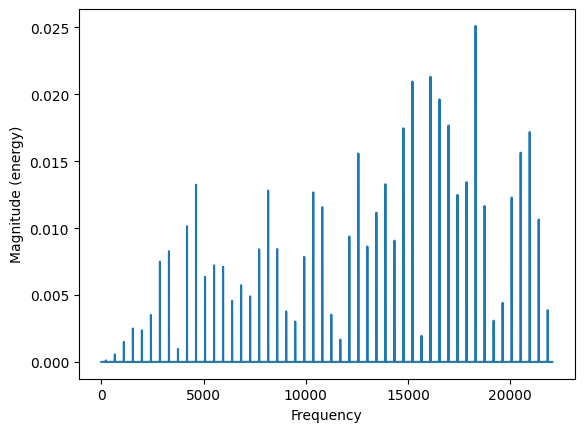

In [23]:
plt.magnitude_spectrum(wt_syn_output, Fs=sample_rate)

In [24]:
Audio(wt_syn_output, rate = sample_rate)

Using Loss Filter

In [28]:
total_samples = int(sample_rate * duration)
tube_len = int(sample_rate / frequency / 2 ) 

open_bc = -0.997
closed_bc = 0.999

left_delay_line = np.zeros(tube_len) #Sound wave traveling from closed to open, incident 
right_delay_line = np.zeros(tube_len) #Sound wave traveling from open to closed, reflected
wt_syn_output=np.zeros(total_samples) #At time zero, no output

#Low Filter Initialization
cutoff_hz = 6000
b, a = butter(1, cutoff_hz / (sample_rate / 2), btype='low')
# initialise state to zero (filter starts with no history)
zi = lfilter_zi(b, a) * 0.0
zi_open   = lfilter_zi(b, a) * 0.0
zi_closed = lfilter_zi(b, a) * 0.0

for i in range(total_samples):
    wt_syn_output[i] = right_delay_line[-1] + left_delay_line[-1] #output is measured at open, right, end
    #new_left_entry = right_delay_line[-1] * open_bc #right wave travels to open end and is reflected

    #using loss filter

    sample_out, zi_open = lfilter(b, a, [right_delay_line[-1]], zi=zi_open)
    new_left_entry = sample_out[0] * -1.0
    
    new_right_entry = left_delay_line[0] * closed_bc #left wave travels to closed end and is bounced

    if i < tube_len:
        new_right_entry += np.random.uniform(-1.0,1.0) #excitation

    left_delay_line = np.append(left_delay_line[1:], new_left_entry) # new entry at right end
    right_delay_line = np.append(new_right_entry, right_delay_line[:-1]) # new entry at left end

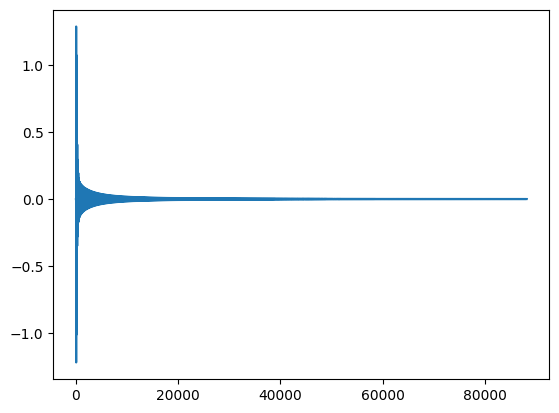

In [29]:
plt.plot(wt_syn_output)

(array([6.83150867e-12, 6.83187447e-12, 6.83297190e-12, ...,
        7.29069343e-10, 7.29071066e-10, 7.29071640e-10], shape=(44101,)),
 array([0.00000e+00, 5.00000e-01, 1.00000e+00, ..., 2.20490e+04,
        2.20495e+04, 2.20500e+04], shape=(44101,)),
 <matplotlib.lines.Line2D at 0x23a6f47d590>)

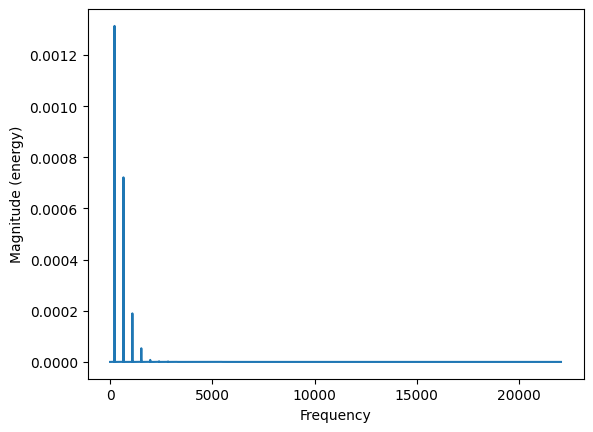

In [30]:
plt.magnitude_spectrum(wt_syn_output, Fs=sample_rate)

In [31]:
Audio(wt_syn_output, rate = sample_rate)